<a href="https://colab.research.google.com/github/zhakhinaaaa/titanic-survival/blob/main/02_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

USER = "zhakhinaaaa"
BASE = f"https://raw.githubusercontent.com/{USER}/titanic-survival/main/data/"

train = pd.read_csv(BASE + "train.csv")
test = pd.read_csv(BASE + "test.csv")

print("train:", train.shape, " test:", test.shape)
train.head()
COLORS = {0: "#eb6834", 1: "#2a78d6"}

train: (891, 12)  test: (418, 11)


In [2]:
full = pd.concat([train, test], keys=["train", "test"])
print(full.shape)   # (1309, 12)

(1309, 12)


In [3]:
full["Title"] = full["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
print(full["Title"].value_counts())

full["Title"] = full["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
full.loc[~full["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Title"] = "Rare"

print(pd.crosstab(full.loc["train", "Title"], full.loc["train", "Survived"],
                  normalize="index").round(2))

Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Don               1
Sir               1
Lady              1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64
Survived   0.0   1.0
Title               
Master    0.42  0.57
Miss      0.30  0.70
Mr        0.84  0.16
Mrs       0.21  0.79
Rare      0.65  0.35


### Титул
Из имени извлекли титул (Mr, Mrs, Miss, Master, Rare). Он объединяет пол, возраст и семейное положение: мужчины (Mr) выживали ~16%, замужние женщины (Mrs) ~79%, мальчики (Master) ~57%.

In [4]:
full["Embarked"] = full["Embarked"].fillna(full.loc["train", "Embarked"].mode()[0])
full["Fare"] = full["Fare"].fillna(full.groupby("Pclass")["Fare"].transform("median"))
full["HasCabin"] = full["Cabin"].notna().astype(int)

print(full.loc["train"].groupby("HasCabin")["Survived"].mean().round(2))

HasCabin
0    0.30
1    0.67
Name: Survived, dtype: float64


### Embarked, Fare, Cabin
Embarked заполнили самым частым портом (S), Fare — медианой по классу. Вместо Cabin создали признак HasCabin: пассажиры с известной каютой выживали примерно в 2 раза чаще, так как это в основном 1-й класс.

In [6]:
full["FamilySize"] = full["SibSp"] + full["Parch"] + 1
full["IsAlone"] = (full["FamilySize"] == 1).astype(int)

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

age_features = ["Pclass", "SibSp", "Parch", "Fare", "FamilySize", "HasCabin"]
X_age = pd.get_dummies(full[age_features + ["Sex", "Title", "Embarked"]], dtype=int)
known = full["Age"].notna()

age_model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
mae_rf = -cross_val_score(age_model, X_age[known], full.loc[known, "Age"],
                          cv=5, scoring="neg_mean_absolute_error").mean()
mae_median = (full.loc[known, "Age"] - full.loc[known, "Age"].median()).abs().mean()
print(f"Ошибка, если ставить медиану всем: {mae_median:.1f} лет")
print(f"Ошибка модели RandomForest:       {mae_rf:.1f} лет")

age_model.fit(X_age[known], full.loc[known, "Age"])
full["AgeWasMissing"] = (~known).astype(int)
full.loc[~known, "Age"] = age_model.predict(X_age[~known]).round(1)
print("Осталось пропусков в Age:", full["Age"].isna().sum())

Ошибка, если ставить медиану всем: 11.2 лет
Ошибка модели RandomForest:       8.2 лет
Осталось пропусков в Age: 0


### Прогноз пропущенного возраста
Пропущенный возраст (263 значения) спрогнозировали моделью RandomForest по классу, полу, титулу, семье и цене билета. Ошибка модели меньше, чем при заполнении медианой, а распределение спрогнозированного возраста похоже на реальное.

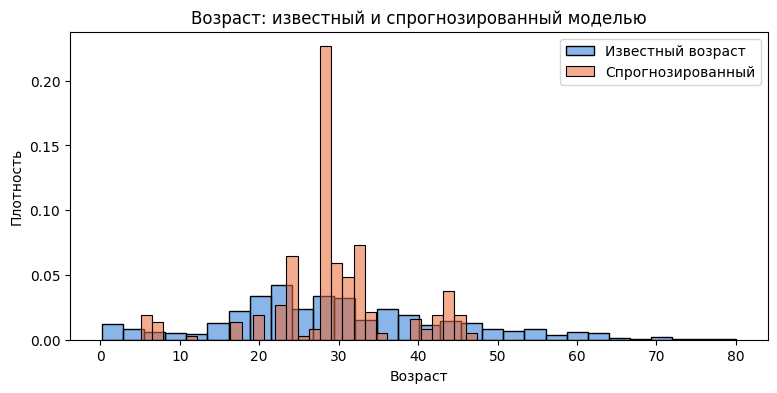

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(full.loc[full["AgeWasMissing"] == 0, "Age"], bins=30, color=COLORS[1],
             alpha=0.55, stat="density", label="Известный возраст", ax=ax)
sns.histplot(full.loc[full["AgeWasMissing"] == 1, "Age"], bins=30, color=COLORS[0],
             alpha=0.55, stat="density", label="Спрогнозированный", ax=ax)
ax.set_title("Возраст: известный и спрогнозированный моделью")
ax.set_xlabel("Возраст"); ax.set_ylabel("Плотность"); ax.legend()
plt.show()

In [9]:
data = full.drop(columns=["PassengerId", "Name", "Ticket", "Cabin", "AgeWasMissing"])
data["Sex"] = (data["Sex"] == "male").astype(int)
data = pd.get_dummies(data, columns=["Embarked", "Title"], dtype=int)

X_train = data.loc["train"].drop(columns="Survived")
y_train = data.loc["train", "Survived"].astype(int)
X_test  = data.loc["test"].drop(columns="Survived")

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Пропусков осталось:", X_train.isna().sum().sum() + X_test.isna().sum().sum())
X_train.head()

X_train: (891, 17)  X_test: (418, 17)
Пропусков осталось: 0


,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,1,22.0,1,0,7.2500,0,2,0,0,0,1,0,0,1,0,0
1,1,0,38.0,1,0,71.2833,1,2,0,1,0,0,0,0,0,1,0
2,3,0,26.0,0,0,7.9250,0,1,1,0,0,1,0,1,0,0,0
3,1,0,35.0,1,0,53.1000,1,2,0,0,0,1,0,0,0,1,0
4,3,1,35.0,0,0,8.0500,0,1,1,0,0,1,0,0,1,0,0


### Итоговые признаки
Удалили PassengerId, Name, Ticket, Cabin. Пол перевели в 0/1, порт и титул — в one-hot столбцы. Получилось 17 признаков без пропусков.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

scaler = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)     # учим scaler только на обучающей части
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
print("Обучение:", X_tr_s.shape, " Проверка:", X_val_s.shape)

Обучение: (712, 17)  Проверка: (179, 17)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(name, y_true, proba):
    pred = (proba >= 0.5).astype(int)
    return {"Модель": name,
            "Accuracy": accuracy_score(y_true, pred),
            "Precision": precision_score(y_true, pred),
            "Recall": recall_score(y_true, pred),
            "F1": f1_score(y_true, pred),
            "ROC-AUC": roc_auc_score(y_true, proba)}

results = []
logreg = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)
results.append(evaluate("Логистическая регрессия", y_val, logreg.predict_proba(X_val_s)[:, 1]))

rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42).fit(X_tr_s, y_tr)
results.append(evaluate("Random Forest", y_val, rf.predict_proba(X_val_s)[:, 1]))

pd.DataFrame(results).round(3)

,Модель,Accuracy,Precision,Recall,F1,ROC-AUC
0,Логистическая регрессия,0.844,0.806,0.783,0.794,0.877
1,Random Forest,0.816,0.790,0.710,0.748,0.853


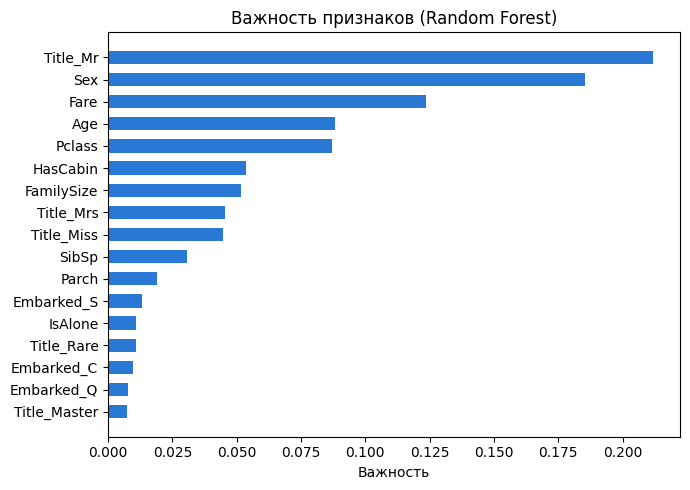

In [12]:
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp.index, imp.values, color=COLORS[1], height=0.6)
ax.set_title("Важность признаков (Random Forest)"); ax.set_xlabel("Важность")
plt.tight_layout(); plt.show()

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

nn = keras.Sequential([
    keras.Input(shape=(X_tr_s.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])
nn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
           loss="binary_crossentropy", metrics=["accuracy"])
nn.summary()

early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=20,
                                      restore_best_weights=True)
history = nn.fit(X_tr_s, y_tr, validation_split=0.2, epochs=300, batch_size=32,
                 callbacks=[early], verbose=0)
print("Обучение остановилось на эпохе", len(history.history["loss"]))

nn_proba = nn.predict(X_val_s, verbose=0).ravel()
results.append(evaluate("Нейросеть (Keras)", y_val, nn_proba))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

Обучение остановилось на эпохе 34


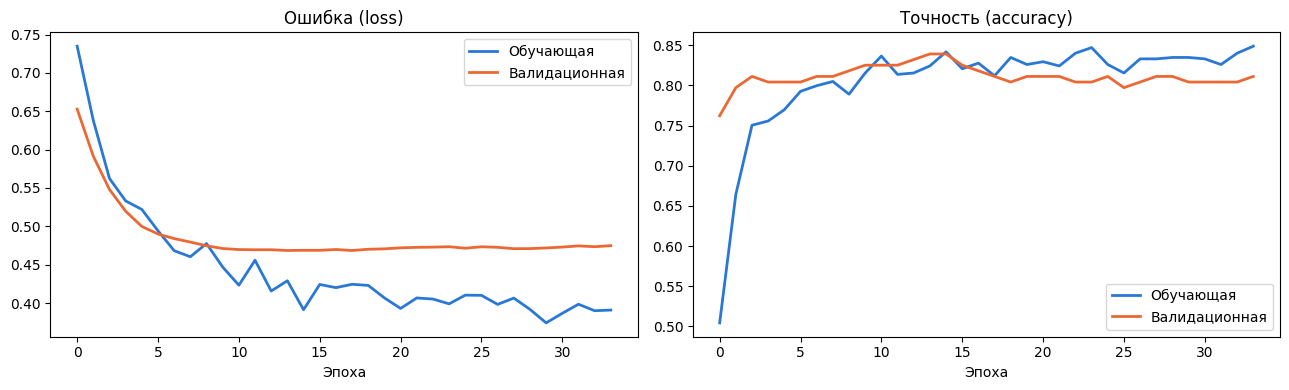

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, key, title in zip(axes, ["loss", "accuracy"], ["Ошибка (loss)", "Точность (accuracy)"]):
    ax.plot(history.history[key], color=COLORS[1], linewidth=2, label="Обучающая")
    ax.plot(history.history["val_" + key], color=COLORS[0], linewidth=2, label="Валидационная")
    ax.set_title(title); ax.set_xlabel("Эпоха"); ax.legend()
plt.tight_layout(); plt.show()

### Обучение нейросети
Ошибка на обучающей выборке продолжает снижаться, а на валидационной выходит на плато примерно после 10-й эпохи — это признак начала переобучения.
Поэтому использован EarlyStopping: обучение остановилось автоматически, и модель вернулась к весам с наименьшей ошибкой на валидации. Dropout-слои дополнительно снижают переобучение.

,Accuracy,Precision,Recall,F1,ROC-AUC
Модель,,,,,
Логистическая регрессия,0.844,0.806,0.783,0.794,0.877
Random Forest,0.816,0.790,0.710,0.748,0.853
Нейросеть (Keras),0.832,0.791,0.768,0.779,0.837


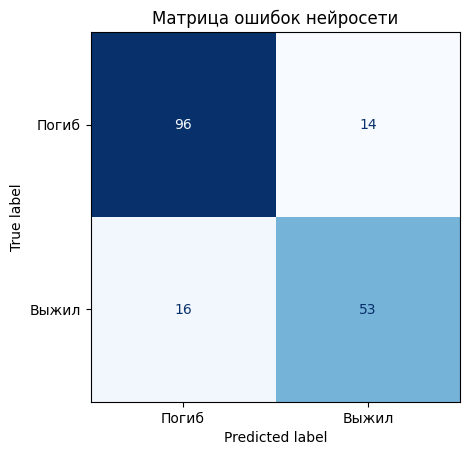

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

table = pd.DataFrame(results).set_index("Модель").round(3)
display(table)

cm = confusion_matrix(y_val, (nn_proba >= 0.5).astype(int))
ConfusionMatrixDisplay(cm, display_labels=["Погиб", "Выжил"]).plot(cmap="Blues", colorbar=False)
plt.title("Матрица ошибок нейросети"); plt.show()

### Сравнение моделей
Все три модели показали близкое качество: accuracy 0.82–0.84, ROC-AUC 0.85–0.88. Лучший результат у логистической регрессии (accuracy 0.844), нейросеть — на уровне классических моделей.
Для небольших табличных данных (891 пассажир) нейросеть не даёт преимущества: закономерности здесь простые (пол, класс, возраст), и их хорошо улавливают и более простые модели.
По матрице ошибок модель чаще ошибается, пропуская выживших (Recall ниже Precision), чем ложно предсказывая спасение.

In [17]:
import joblib, json
nn.save("titanic_model.keras")
joblib.dump(scaler, "scaler.pkl")
with open("columns.json", "w") as f:
    json.dump(list(X_train.columns), f)

from google.colab import files
for f in ["titanic_model.keras", "scaler.pkl", "columns.json"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>